# Text Diff Analysis

**Paper 2: Cross-Code Comparative Analysis - Part 10**

This notebook analyzes text changes between consecutive versions of Kazakhstan legal codes.

## Objectives
1. Compute text diffs between consecutive versions
2. Analyze character-level and token-level changes
3. Identify most heavily amended articles
4. Visualize amendment patterns over time
5. Track specific types of changes (additions, deletions, modifications)

## 1. Setup and Imports

In [10]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
from collections import defaultdict
import difflib
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Paths
DATA_DIR = Path('../data/raw/by_history')
OUTPUT_08 = Path('../output/08')
OUTPUT_09 = Path('../output/09')
OUTPUT_DIR = Path('../output/10')
OUTPUT_DIR.mkdir(exist_ok=True)

# Code metadata
CODES = {
    'civil': {'folder': 'K940001000__rus_grazh', 'short': 'ГК', 'name': 'Гражданский кодекс'},
    'criminal': {'folder': 'K1400000226_rus_ugolov', 'short': 'УК', 'name': 'Уголовный кодекс'},
    'administrative': {'folder': 'K1400000235_rus_adm', 'short': 'КоАП', 'name': 'Кодекс об административных правонарушениях'},
    'labor': {'folder': 'K1500000414_rus_trud', 'short': 'ТК', 'name': 'Трудовой кодекс'},
}

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Setup complete!")

Setup complete!


## 2. Load Version Index and Previous Results

In [11]:
# Load consolidated index from notebook 08
with open(OUTPUT_08 / 'consolidated_version_index.json', 'r', encoding='utf-8') as f:
    consolidated_index = json.load(f)

# Load lifecycle events from notebook 09
events_df = pd.read_csv(OUTPUT_09 / 'article_lifecycle_events.csv')
lifespans_df = pd.read_csv(OUTPUT_09 / 'article_lifespans.csv')

def get_version_list(code_folder):
    """Build version list from directory listing."""
    folder_path = DATA_DIR / code_folder
    version_files = sorted(folder_path.glob('version_*.json'))
    
    versions = []
    for vf in version_files:
        # Parse filename: version_001_1996-07-15.json
        parts = vf.stem.split('_')
        version_num = int(parts[1])
        version_date = parts[2]
        versions.append({
            'version_number': version_num,
            'version_date': version_date,
            'filename': vf.name
        })
    return versions

# Build version indices for all codes
all_indices = {}
for code_key, code_info in CODES.items():
    versions = get_version_list(code_info['folder'])
    all_indices[code_key] = {
        'total_versions': len(versions),
        'versions': versions
    }

print("Loaded data from previous notebooks:")
for code_key, idx in all_indices.items():
    print(f"  {CODES[code_key]['short']}: {idx['total_versions']} versions")

print(f"\nLifecycle events: {len(events_df):,}")
print(f"Article lifespans: {len(lifespans_df):,}")

Loaded data from previous notebooks:
  ГК: 179 versions
  УК: 109 versions
  КоАП: 205 versions
  ТК: 69 versions

Lifecycle events: 10,397
Article lifespans: 2,214


In [12]:
def load_version_file(code_folder, filename):
    """Load a specific version file."""
    filepath = DATA_DIR / code_folder / filename
    with open(filepath, 'r', encoding='utf-8') as f:
        return json.load(f)

def get_article_text(version_data, article_number):
    """Extract article text by article number."""
    for art in version_data.get('articles', []):
        title = art.get('article_title', '')
        # Match article number in title
        if f'Статья {article_number}.' in title or f'Статья {article_number} ' in title:
            return art.get('article_text', '')
    return None

def extract_article_number(title):
    """Extract article number from title."""
    match = re.search(r'Статья\s+([\d\-]+)', title)
    return match.group(1) if match else None

print("Helper functions defined.")

Helper functions defined.


## 3. Text Diff Analysis Functions

In [13]:
def compute_text_diff(text1, text2):
    """
    Compute detailed diff metrics between two texts.
    Returns dict with various change metrics.
    """
    if not text1 or not text2:
        return None
    
    # Character-level metrics
    char_ratio = difflib.SequenceMatcher(None, text1, text2).ratio()
    
    # Token-level metrics (words)
    words1 = text1.split()
    words2 = text2.split()
    word_ratio = difflib.SequenceMatcher(None, words1, words2).ratio()
    
    # Get opcodes for detailed analysis
    matcher = difflib.SequenceMatcher(None, words1, words2)
    opcodes = matcher.get_opcodes()
    
    # Count operations
    n_equal = 0
    n_replace = 0
    n_insert = 0
    n_delete = 0
    
    for tag, i1, i2, j1, j2 in opcodes:
        if tag == 'equal':
            n_equal += (i2 - i1)
        elif tag == 'replace':
            n_replace += max(i2 - i1, j2 - j1)
        elif tag == 'insert':
            n_insert += (j2 - j1)
        elif tag == 'delete':
            n_delete += (i2 - i1)
    
    total_words = max(len(words1), len(words2))
    
    return {
        'char_similarity': char_ratio,
        'word_similarity': word_ratio,
        'chars_before': len(text1),
        'chars_after': len(text2),
        'char_change': len(text2) - len(text1),
        'words_before': len(words1),
        'words_after': len(words2),
        'word_change': len(words2) - len(words1),
        'words_equal': n_equal,
        'words_replaced': n_replace,
        'words_inserted': n_insert,
        'words_deleted': n_delete,
        'change_ratio': (n_replace + n_insert + n_delete) / total_words if total_words > 0 else 0
    }

# Test the function
test_diff = compute_text_diff(
    "Статья устанавливает порядок регистрации юридических лиц.",
    "Статья устанавливает новый порядок государственной регистрации юридических лиц и индивидуальных предпринимателей."
)
print("Test diff result:")
for k, v in test_diff.items():
    print(f"  {k}: {v}")

Test diff result:
  char_similarity: 0.6705882352941176
  word_similarity: 0.5882352941176471
  chars_before: 57
  chars_after: 113
  char_change: 56
  words_before: 6
  words_after: 11
  word_change: 5
  words_equal: 5
  words_replaced: 4
  words_inserted: 2
  words_deleted: 0
  change_ratio: 0.5454545454545454


## 4. Compute Diffs for All Version Transitions

In [14]:
def analyze_version_transition(code_key, version_from, version_to):
    """
    Analyze all article changes between two consecutive versions.
    """
    code_info = CODES[code_key]
    
    # Load both versions
    data_from = load_version_file(code_info['folder'], version_from['filename'])
    data_to = load_version_file(code_info['folder'], version_to['filename'])
    
    # Build article dictionaries
    articles_from = {}
    for art in data_from.get('articles', []):
        art_num = extract_article_number(art.get('article_title', ''))
        if art_num:
            articles_from[art_num] = art.get('article_text', '')
    
    articles_to = {}
    for art in data_to.get('articles', []):
        art_num = extract_article_number(art.get('article_title', ''))
        if art_num:
            articles_to[art_num] = art.get('article_text', '')
    
    # Compare articles
    changes = []
    
    # Check modified and deleted articles
    for art_num, text_from in articles_from.items():
        if art_num in articles_to:
            text_to = articles_to[art_num]
            if text_from != text_to:
                diff_metrics = compute_text_diff(text_from, text_to)
                if diff_metrics:
                    changes.append({
                        'article_number': art_num,
                        'change_type': 'modified',
                        **diff_metrics
                    })
    
    return changes

print("Version transition analysis function defined.")

Version transition analysis function defined.


In [15]:
# Analyze all version transitions for all codes
all_diffs = []

for code_key in ['civil', 'criminal', 'administrative', 'labor']:
    code_info = CODES[code_key]
    versions = all_indices[code_key]['versions']
    
    print(f"\nAnalyzing {code_info['short']} ({len(versions)} versions)...")
    
    for i in tqdm(range(1, len(versions)), desc=code_info['short']):
        version_from = versions[i-1]
        version_to = versions[i]
        
        try:
            changes = analyze_version_transition(code_key, version_from, version_to)
            
            for change in changes:
                change['code_key'] = code_key
                change['code_short'] = code_info['short']
                change['version_from'] = version_from['version_number']
                change['version_to'] = version_to['version_number']
                change['date'] = version_to['version_date']
                all_diffs.append(change)
                
        except Exception as e:
            print(f"  Error processing v{version_from['version_number']} -> v{version_to['version_number']}: {e}")

diffs_df = pd.DataFrame(all_diffs)
diffs_df


Analyzing ГК (179 versions)...


ГК: 100%|██████████| 178/178 [00:06<00:00, 27.33it/s]



Analyzing УК (109 versions)...


УК: 100%|██████████| 108/108 [00:07<00:00, 14.81it/s]



Analyzing КоАП (205 versions)...


КоАП: 100%|██████████| 204/204 [00:25<00:00,  8.00it/s]



Analyzing ТК (69 versions)...


ТК: 100%|██████████| 68/68 [00:02<00:00, 27.46it/s]


,article_number,change_type,char_similarity,word_similarity,chars_before,chars_after,char_change,words_before,words_after,word_change,words_equal,words_replaced,words_inserted,words_deleted,change_ratio,code_key,code_short,version_from,version_to,date
0,86,modified,0.924480,0.929245,1622,1887,265,197,227,30,197,0,30,0,0.132159,civil,ГК,1,2,1996-12-07
1,90,modified,0.996785,0.995516,936,930,-6,112,111,-1,111,0,0,1,0.008929,civil,ГК,1,2,1996-12-07
2,49,modified,0.870595,0.858586,1433,1859,426,170,226,56,170,0,56,0,0.247788,civil,ГК,2,3,1997-01-21
3,50,modified,0.998168,0.994949,3275,3275,0,396,396,0,394,2,0,0,0.005051,civil,ГК,2,3,1997-01-21
4,51,modified,0.867010,0.904594,2264,2398,134,272,294,22,256,0,38,16,0.183673,civil,ГК,2,3,1997-01-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8220,132,modified,0.916392,0.901099,696,823,127,82,100,18,82,0,18,0,0.180000,labor,ТК,64,65,2025-06-26
8221,22,modified,0.977349,0.973708,4358,4560,202,538,565,27,537,28,0,0,0.049558,labor,ТК,67,68,2025-08-25
8222,65,modified,0.972333,0.966622,3040,3213,173,363,386,23,362,24,0,0,0.062176,labor,ТК,67,68,2025-08-25
8223,66,modified,0.966187,0.959481,2486,2660,174,297,320,23,296,24,0,0,0.075000,labor,ТК,67,68,2025-08-25


In [16]:
# Parse dates and add time columns
diffs_df['date'] = pd.to_datetime(diffs_df['date'], format='%Y-%m-%d', errors='coerce')
diffs_df['year'] = diffs_df['date'].dt.year
diffs_df['month'] = diffs_df['date'].dt.month

# Summary statistics
print("Text Diff Summary:")
print("=" * 60)
print(f"Total changes: {len(diffs_df):,}")
print(f"\nChanges by code:")
print(diffs_df.groupby('code_short').size())

print(f"\nSimilarity statistics:")
print(diffs_df[['char_similarity', 'word_similarity']].describe())

Text Diff Summary:
Total changes: 8,225

Changes by code:
code_short
ГК      2849
КоАП    3561
ТК       585
УК      1230
dtype: int64

Similarity statistics:
       char_similarity  word_similarity
count      8225.000000      8225.000000
mean          0.913276         0.918300
std           0.146642         0.112434
min           0.004706         0.031250
25%           0.912987         0.902174
50%           0.960248         0.954248
75%           0.987028         0.983508
max           0.999979         1.000000


## 5. Categorize Changes by Magnitude

In [17]:
# Categorize changes
def categorize_change(row):
    sim = row['word_similarity']
    if sim >= 0.95:
        return 'Cosmetic'
    elif sim >= 0.85:
        return 'Minor'
    elif sim >= 0.70:
        return 'Moderate'
    elif sim >= 0.50:
        return 'Significant'
    else:
        return 'Major Rewrite'

diffs_df['change_category'] = diffs_df.apply(categorize_change, axis=1)

# Show distribution
print("Change Category Distribution:")
print("=" * 60)
category_counts = diffs_df['change_category'].value_counts()
for cat in ['Cosmetic', 'Minor', 'Moderate', 'Significant', 'Major Rewrite']:
    count = category_counts.get(cat, 0)
    pct = count / len(diffs_df) * 100
    print(f"{cat:<15}: {count:>6,} ({pct:>5.1f}%)")

print("\nBy Code and Category:")
print(pd.crosstab(diffs_df['code_short'], diffs_df['change_category'], margins=True))

Change Category Distribution:
Cosmetic       :  4,320 ( 52.5%)
Minor          :  2,749 ( 33.4%)
Moderate       :    758 (  9.2%)
Significant    :    252 (  3.1%)
Major Rewrite  :    146 (  1.8%)

By Code and Category:
change_category  Cosmetic  Major Rewrite  Minor  Moderate  Significant   All
code_short                                                                  
ГК                   1355             52   1089       284           69  2849
КоАП                 1800             78   1198       343          142  3561
ТК                    390              5    131        48           11   585
УК                    775             11    331        83           30  1230
All                  4320            146   2749       758          252  8225


## 6. Identify Most Heavily Amended Articles

In [18]:
# Aggregate changes per article
article_changes = diffs_df.groupby(['code_key', 'code_short', 'article_number']).agg({
    'char_similarity': ['mean', 'min', 'count'],
    'word_similarity': ['mean', 'min'],
    'words_inserted': 'sum',
    'words_deleted': 'sum',
    'words_replaced': 'sum',
    'char_change': 'sum'
}).reset_index()

# Flatten column names
article_changes.columns = ['code_key', 'code_short', 'article_number', 
                           'mean_char_sim', 'min_char_sim', 'change_count',
                           'mean_word_sim', 'min_word_sim',
                           'total_words_inserted', 'total_words_deleted', 
                           'total_words_replaced', 'total_char_change']

# Calculate total change magnitude
article_changes['total_word_changes'] = (article_changes['total_words_inserted'] + 
                                          article_changes['total_words_deleted'] + 
                                          article_changes['total_words_replaced'])

# Volatility score (combines frequency and magnitude)
article_changes['volatility_score'] = (article_changes['change_count'] * 
                                        (1 - article_changes['mean_word_sim']))

print("Most Heavily Amended Articles (by total word changes):")
print("=" * 80)
top_amended = article_changes.nlargest(15, 'total_word_changes')
for _, row in top_amended.iterrows():
    print(f"{row['code_short']:<5} Ст.{row['article_number']:<8} | "
          f"{row['change_count']:>3} changes | "
          f"{row['total_word_changes']:>6,} words changed | "
          f"avg sim: {row['mean_word_sim']:.3f}")

Most Heavily Amended Articles (by total word changes):
КоАП  Ст.804      |  67 changes |  5,454 words changed | avg sim: 0.986
КоАП  Ст.684      |  66 changes |  1,945 words changed | avg sim: 0.981
КоАП  Ст.637      |  15 changes |  1,814 words changed | avg sim: 0.931
КоАП  Ст.282      |  17 changes |  1,806 words changed | avg sim: 0.935
КоАП  Ст.228      |  18 changes |  1,783 words changed | avg sim: 0.906
УК    Ст.3        |  40 changes |  1,709 words changed | avg sim: 0.993
ГК    Ст.50       |  30 changes |  1,660 words changed | avg sim: 0.950
КоАП  Ст.207      |  11 changes |  1,504 words changed | avg sim: 0.930
КоАП  Ст.409      |  19 changes |  1,464 words changed | avg sim: 0.949
КоАП  Ст.729      |  32 changes |  1,270 words changed | avg sim: 0.942
КоАП  Ст.214      |  11 changes |  1,250 words changed | avg sim: 0.913
КоАП  Ст.685      |  28 changes |  1,223 words changed | avg sim: 0.975
ГК    Ст.59       |  31 changes |  1,221 words changed | avg sim: 0.942
ГК    Ст.

In [19]:
# Most volatile articles (highest volatility score)
print("\nMost Volatile Articles (high frequency + low similarity):")
print("=" * 80)
top_volatile = article_changes.nlargest(15, 'volatility_score')
for _, row in top_volatile.iterrows():
    print(f"{row['code_short']:<5} Ст.{row['article_number']:<8} | "
          f"volatility: {row['volatility_score']:.2f} | "
          f"{row['change_count']:>3} changes | "
          f"min sim: {row['min_word_sim']:.3f}")


Most Volatile Articles (high frequency + low similarity):
ГК    Ст.368      | volatility: 4.73 |  10 changes | min sim: 0.340
ГК    Ст.88       | volatility: 4.28 |  11 changes | min sim: 0.103
ГК    Ст.87       | volatility: 3.34 |  14 changes | min sim: 0.435
ГК    Ст.93       | volatility: 3.13 |  19 changes | min sim: 0.659
ГК    Ст.83       | volatility: 3.03 |  15 changes | min sim: 0.667
ГК    Ст.54       | volatility: 2.94 |  11 changes | min sim: 0.046
ГК    Ст.52       | volatility: 2.93 |  14 changes | min sim: 0.264
ГК    Ст.16       | volatility: 2.92 |  17 changes | min sim: 0.463
ГК    Ст.136      | volatility: 2.91 |  14 changes | min sim: 0.339
ГК    Ст.78       | volatility: 2.77 |  15 changes | min sim: 0.420
ГК    Ст.193      | volatility: 2.70 |  13 changes | min sim: 0.537
ГК    Ст.64       | volatility: 2.69 |  10 changes | min sim: 0.413
КоАП  Ст.850      | volatility: 2.68 |   6 changes | min sim: 0.458
ГК    Ст.53       | volatility: 2.56 |  15 changes | min 

## 7. Visualizations

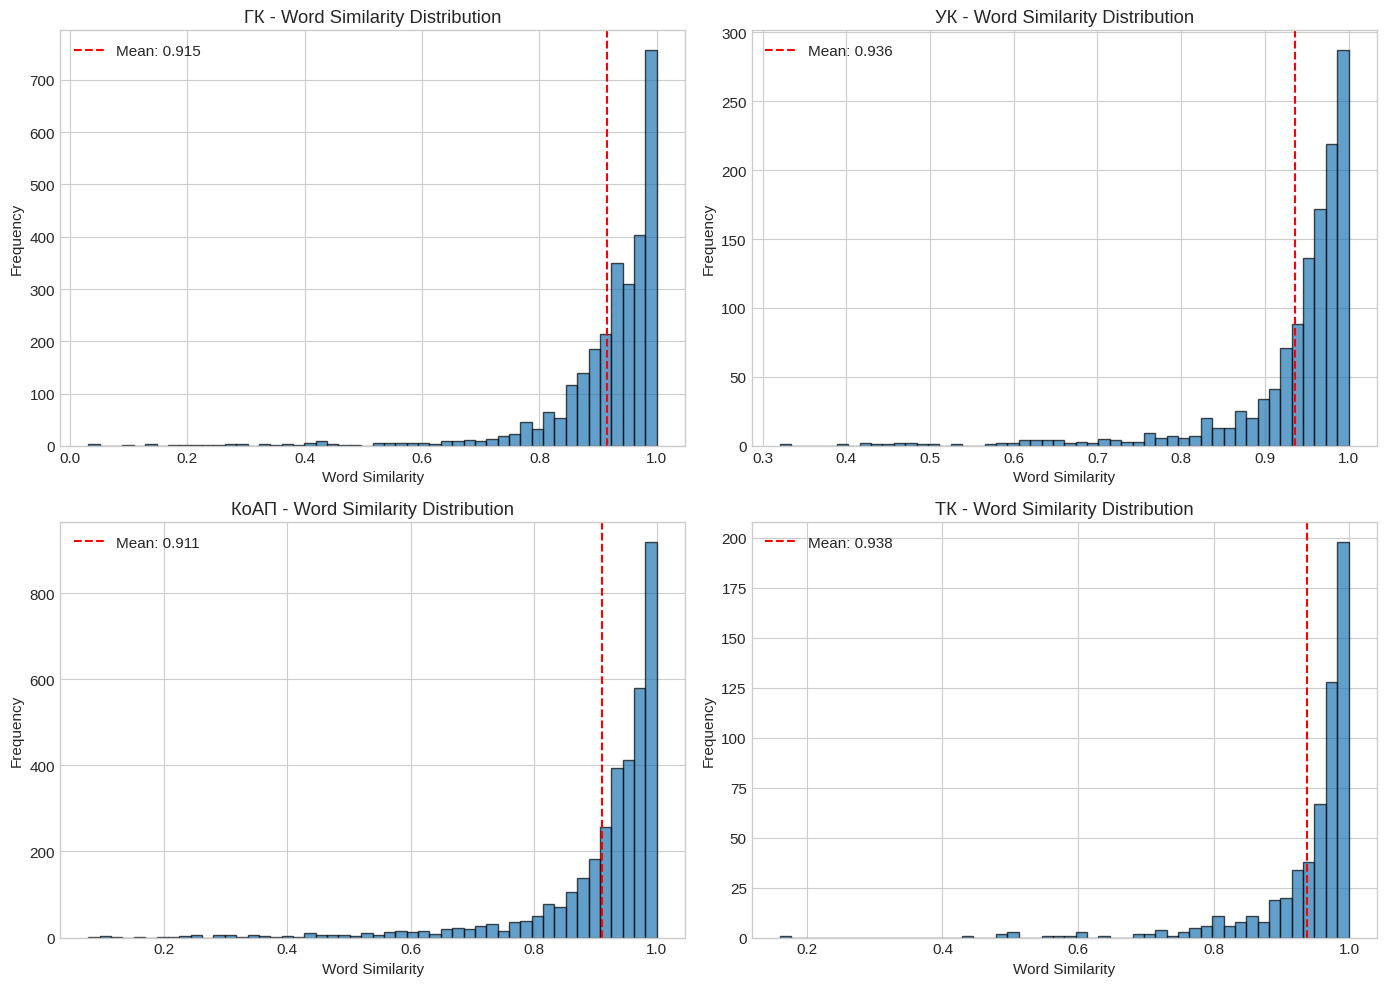

In [20]:
# Change magnitude distribution by code
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, code_key in enumerate(['civil', 'criminal', 'administrative', 'labor']):
    ax = axes[idx // 2, idx % 2]
    code_data = diffs_df[diffs_df['code_key'] == code_key]
    
    ax.hist(code_data['word_similarity'], bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(code_data['word_similarity'].mean(), color='red', linestyle='--', 
               label=f'Mean: {code_data["word_similarity"].mean():.3f}')
    ax.set_xlabel('Word Similarity')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{CODES[code_key]["short"]} - Word Similarity Distribution')
    ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'word_similarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

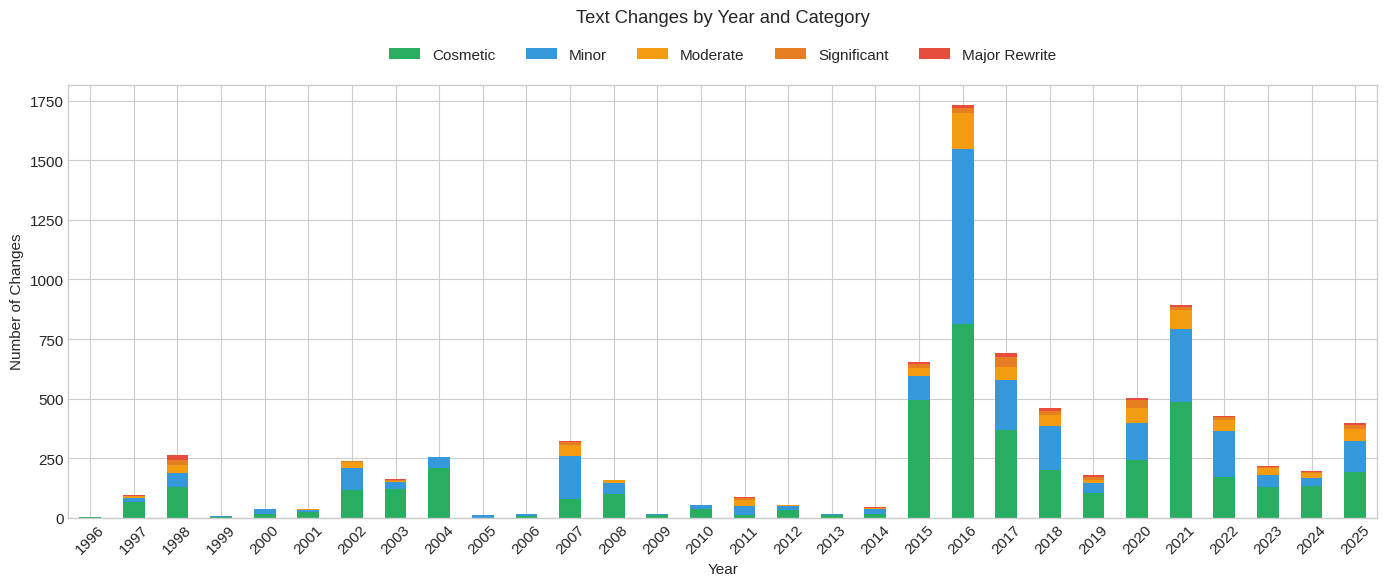

In [28]:
# Changes over time by category
fig, ax = plt.subplots(figsize=(14, 6))

yearly_by_category = diffs_df.groupby(['year', 'change_category']).size().unstack(fill_value=0)

# Reorder categories
category_order = ['Cosmetic', 'Minor', 'Moderate', 'Significant', 'Major Rewrite']
yearly_by_category = yearly_by_category[[c for c in category_order if c in yearly_by_category.columns]]

colors = ['#27ae60', '#3498db', '#f39c12', '#e67e22', '#e74c3c']
yearly_by_category.plot(kind='bar', stacked=True, ax=ax, color=colors[:len(yearly_by_category.columns)])

ax.set_xlabel('Year')
ax.set_ylabel('Number of Changes')
ax.set_title('Text Changes by Year and Category', pad=45)
ax.legend(title=None, bbox_to_anchor=(0.5, 1.02), loc='lower center', ncol=5)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'changes_by_year_category.png', dpi=150, bbox_inches='tight')
plt.show()

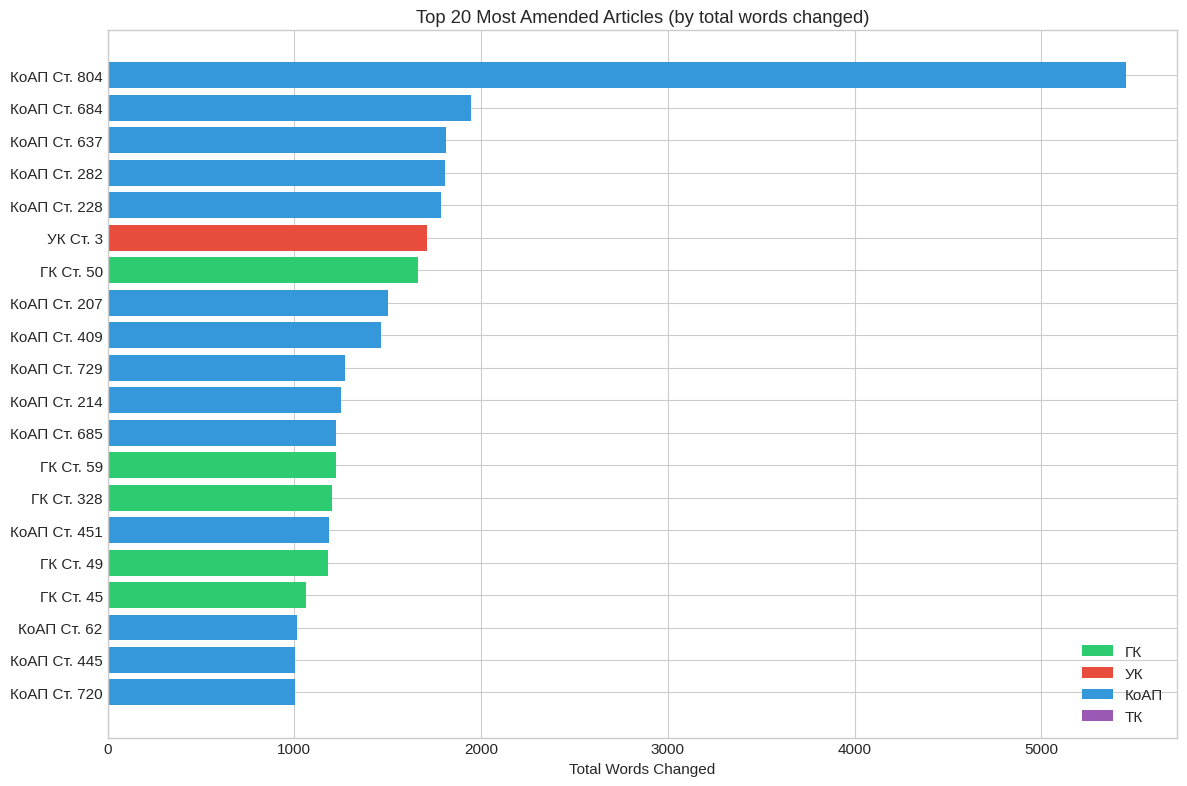

In [30]:
# Top 20 most amended articles visualization
fig, ax = plt.subplots(figsize=(12, 8))

top20 = article_changes.nlargest(20, 'total_word_changes')
top20['label'] = top20['code_short'] + ' Ст. ' + top20['article_number'].astype(str)

colors = {'ГК': '#2ecc71', 'УК': '#e74c3c', 'КоАП': '#3498db', 'ТК': '#9b59b6'}
bar_colors = [colors[code] for code in top20['code_short']]

bars = ax.barh(range(len(top20)), top20['total_word_changes'], color=bar_colors)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['label'])
ax.invert_yaxis()
ax.set_xlabel('Total Words Changed')
ax.set_title('Top 20 Most Amended Articles (by total words changed)')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[k], label=k) for k in colors]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top_amended_articles.png', dpi=150, bbox_inches='tight')
plt.show()

## 7.1 Net Text Growth per Code

Are articles getting longer or shorter over time?

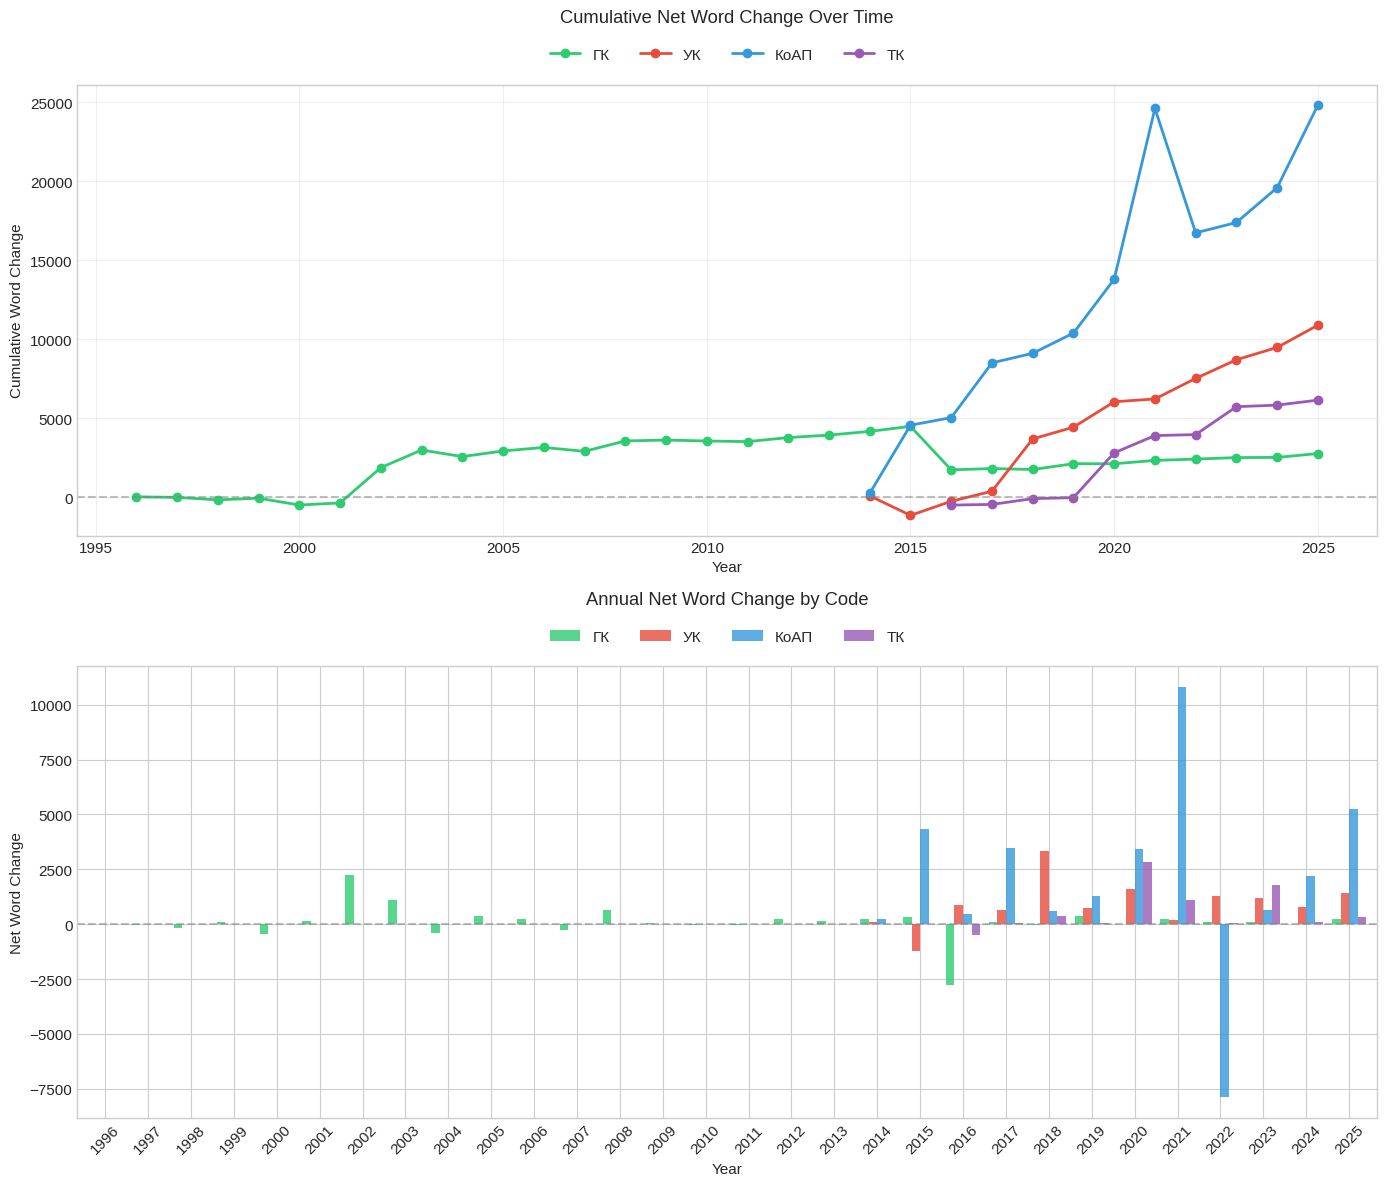


Net Text Growth Summary:
ГК   :   +2,770 words (   +26,757 chars) - growing
УК   :  +10,901 words (   +82,823 chars) - growing
КоАП :  +24,839 words (  +211,956 chars) - growing
ТК   :   +6,153 words (   +52,664 chars) - growing


In [36]:
# Net Text Growth per Code - Are articles getting longer or shorter?
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Calculate cumulative word change per code over time
yearly_growth = diffs_df.groupby(['year', 'code_key']).agg({
    'word_change': 'sum',
    'char_change': 'sum'
}).reset_index()

colors = {'civil': '#2ecc71', 'criminal': '#e74c3c', 'administrative': '#3498db', 'labor': '#9b59b6'}

# Top: Cumulative word change
ax1 = axes[0]
for code_key in ['civil', 'criminal', 'administrative', 'labor']:
    code_data = yearly_growth[yearly_growth['code_key'] == code_key].sort_values('year')
    code_data['cumulative_words'] = code_data['word_change'].cumsum()
    ax1.plot(code_data['year'], code_data['cumulative_words'], 
             marker='o', label=CODES[code_key]['short'], color=colors[code_key], linewidth=2)

ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Year')
ax1.set_ylabel('Cumulative Word Change')
ax1.set_title('Cumulative Net Word Change Over Time', pad=45)
ax1.legend(title=None, bbox_to_anchor=(0.5, 1.02), loc='lower center', ncol=4)
ax1.grid(True, alpha=0.3)

# Bottom: Annual word change by code
ax2 = axes[1]
pivot_growth = yearly_growth.pivot(index='year', columns='code_key', values='word_change').fillna(0)
pivot_growth = pivot_growth[['civil', 'criminal', 'administrative', 'labor']]
pivot_growth.columns = [CODES[k]['short'] for k in pivot_growth.columns]

pivot_growth.plot(kind='bar', ax=ax2, color=[colors[k] for k in ['civil', 'criminal', 'administrative', 'labor']], 
                  width=0.8, alpha=0.8)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Year')
ax2.set_ylabel('Net Word Change')
ax2.set_title('Annual Net Word Change by Code', pad=45)
ax2.legend(title=None, bbox_to_anchor=(0.5, 1.02), loc='lower center', ncol=4)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'net_text_growth.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("\nNet Text Growth Summary:")
print("=" * 60)
for code_key in ['civil', 'criminal', 'administrative', 'labor']:
    code_data = yearly_growth[yearly_growth['code_key'] == code_key]
    total_words = code_data['word_change'].sum()
    total_chars = code_data['char_change'].sum()
    direction = "growing" if total_words > 0 else "shrinking"
    print(f"{CODES[code_key]['short']:<5}: {total_words:>+8,} words ({total_chars:>+10,} chars) - {direction}")

## 7.2 Change Velocity and Acceleration

Is the magnitude of changes increasing or decreasing over time?

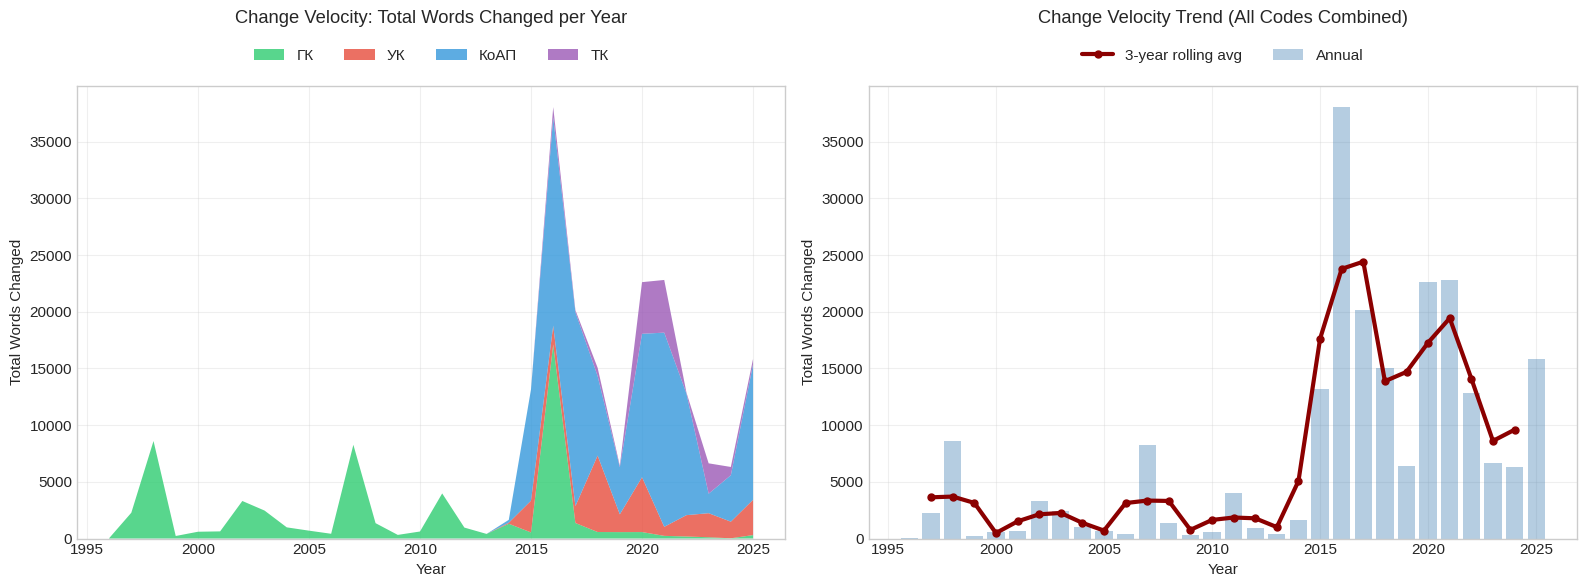


Change Velocity Analysis:
Recent 5-year trend: decelerating (-1,354 words/year on average)

Peak years by total words changed:
  2016:     38,052 words
  2021:     22,807 words
  2020:     22,613 words
  2017:     20,143 words
  2025:     15,843 words


In [37]:
# Change Velocity - Total words changed per year (magnitude, not direction)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculate total change magnitude per year
yearly_velocity = diffs_df.groupby(['year', 'code_key']).agg({
    'words_inserted': 'sum',
    'words_deleted': 'sum',
    'words_replaced': 'sum',
    'article_number': 'count'  # Number of changes
}).reset_index()
yearly_velocity['total_words_changed'] = (yearly_velocity['words_inserted'] + 
                                           yearly_velocity['words_deleted'] + 
                                           yearly_velocity['words_replaced'])
yearly_velocity.rename(columns={'article_number': 'change_count'}, inplace=True)

colors = {'civil': '#2ecc71', 'criminal': '#e74c3c', 'administrative': '#3498db', 'labor': '#9b59b6'}

# Left: Total words changed per year (stacked area)
ax1 = axes[0]
pivot_velocity = yearly_velocity.pivot(index='year', columns='code_key', values='total_words_changed').fillna(0)
pivot_velocity = pivot_velocity[['civil', 'criminal', 'administrative', 'labor']]

ax1.stackplot(pivot_velocity.index, 
              [pivot_velocity[k] for k in ['civil', 'criminal', 'administrative', 'labor']],
              labels=[CODES[k]['short'] for k in ['civil', 'criminal', 'administrative', 'labor']],
              colors=[colors[k] for k in ['civil', 'criminal', 'administrative', 'labor']],
              alpha=0.8)
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Words Changed')
ax1.set_title('Change Velocity: Total Words Changed per Year', pad=45)
ax1.legend(title=None, bbox_to_anchor=(0.5, 1.02), loc='lower center', ncol=4)
ax1.grid(True, alpha=0.3)

# Right: 3-year rolling average to show trend
ax2 = axes[1]
total_by_year = yearly_velocity.groupby('year')['total_words_changed'].sum()
rolling_avg = total_by_year.rolling(window=3, center=True).mean()

ax2.bar(total_by_year.index, total_by_year.values, alpha=0.4, color='steelblue', label='Annual')
ax2.plot(rolling_avg.index, rolling_avg.values, color='darkred', linewidth=3, 
         marker='o', markersize=5, label='3-year rolling avg')
ax2.set_xlabel('Year')
ax2.set_ylabel('Total Words Changed')
ax2.set_title('Change Velocity Trend (All Codes Combined)', pad=45)
ax2.legend(title=None, bbox_to_anchor=(0.5, 1.02), loc='lower center', ncol=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'change_velocity.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate acceleration (year-over-year change in velocity)
print("\nChange Velocity Analysis:")
print("=" * 60)
yoy_change = total_by_year.diff()
recent_trend = yoy_change.tail(5).mean()
overall_trend = "accelerating" if recent_trend > 0 else "decelerating"
print(f"Recent 5-year trend: {overall_trend} ({recent_trend:+,.0f} words/year on average)")
print(f"\nPeak years by total words changed:")
for year in total_by_year.nlargest(5).index:
    print(f"  {year}: {total_by_year[year]:>10,.0f} words")

## 7.3 Cross-Code Amendment Correlation

When one code is heavily amended, are others also amended?

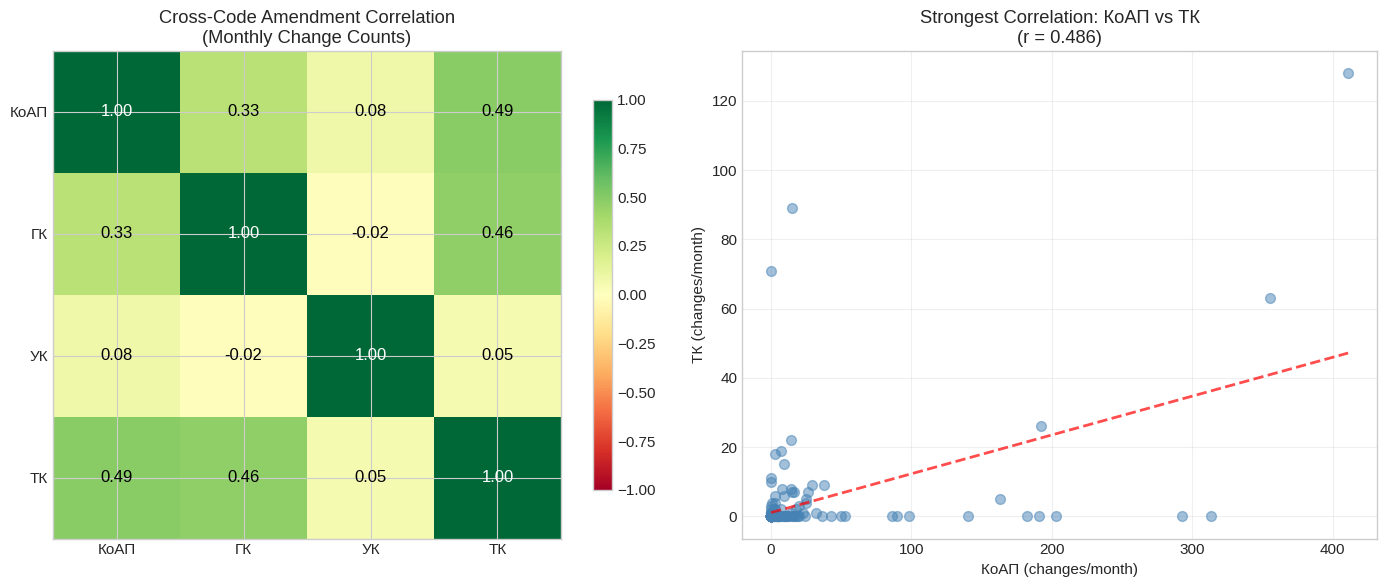


Cross-Code Amendment Correlation Analysis:

Correlation pairs (by strength):
  КоАП <-> ТК:  0.486 (moderate)
  ГК <-> ТК:  0.464 (moderate)
  КоАП <-> ГК:  0.327 (weak)
  КоАП <-> УК:  0.078 (weak)
  УК <-> ТК:  0.052 (weak)
  ГК <-> УК: -0.015 (weak)

INSIGHT: High correlation suggests codes are often amended together,
possibly due to comprehensive legislative packages or related reforms.


In [38]:
# Cross-Code Amendment Correlation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Create monthly change counts per code
diffs_df['year_month'] = diffs_df['date'].dt.to_period('M')
monthly_changes = diffs_df.groupby(['year_month', 'code_key']).size().unstack(fill_value=0)

# Rename columns for clarity
monthly_changes.columns = [CODES[c]['short'] for c in monthly_changes.columns]

# Calculate correlation matrix
correlation_matrix = monthly_changes.corr()

# Left: Correlation heatmap
ax1 = axes[0]
im = ax1.imshow(correlation_matrix, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=1)
ax1.set_xticks(range(len(correlation_matrix.columns)))
ax1.set_yticks(range(len(correlation_matrix.columns)))
ax1.set_xticklabels(correlation_matrix.columns)
ax1.set_yticklabels(correlation_matrix.columns)
ax1.set_title('Cross-Code Amendment Correlation\n(Monthly Change Counts)')

# Add correlation values as text
for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        val = correlation_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax1.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=12)

plt.colorbar(im, ax=ax1, shrink=0.8)

# Right: Scatter plot of most correlated pair
ax2 = axes[1]
# Find highest correlation (excluding diagonal)
corr_pairs = []
for i, col1 in enumerate(correlation_matrix.columns):
    for j, col2 in enumerate(correlation_matrix.columns):
        if i < j:
            corr_pairs.append((col1, col2, correlation_matrix.loc[col1, col2]))

corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
top_pair = corr_pairs[0]

ax2.scatter(monthly_changes[top_pair[0]], monthly_changes[top_pair[1]], 
            alpha=0.5, s=50, c='steelblue')
ax2.set_xlabel(f'{top_pair[0]} (changes/month)')
ax2.set_ylabel(f'{top_pair[1]} (changes/month)')
ax2.set_title(f'Strongest Correlation: {top_pair[0]} vs {top_pair[1]}\n(r = {top_pair[2]:.3f})')

# Add trend line
z = np.polyfit(monthly_changes[top_pair[0]], monthly_changes[top_pair[1]], 1)
p = np.poly1d(z)
x_line = np.linspace(monthly_changes[top_pair[0]].min(), monthly_changes[top_pair[0]].max(), 100)
ax2.plot(x_line, p(x_line), 'r--', linewidth=2, alpha=0.7)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cross_code_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print correlation insights
print("\nCross-Code Amendment Correlation Analysis:")
print("=" * 60)
print("\nCorrelation pairs (by strength):")
for col1, col2, corr in corr_pairs:
    strength = "strong" if abs(corr) > 0.6 else "moderate" if abs(corr) > 0.4 else "weak"
    print(f"  {col1} <-> {col2}: {corr:>6.3f} ({strength})")

print("\nINSIGHT: High correlation suggests codes are often amended together,")
print("possibly due to comprehensive legislative packages or related reforms.")

## 7.4 Change Type Breakdown Over Time

How do insertions, deletions, and replacements compare over the years?

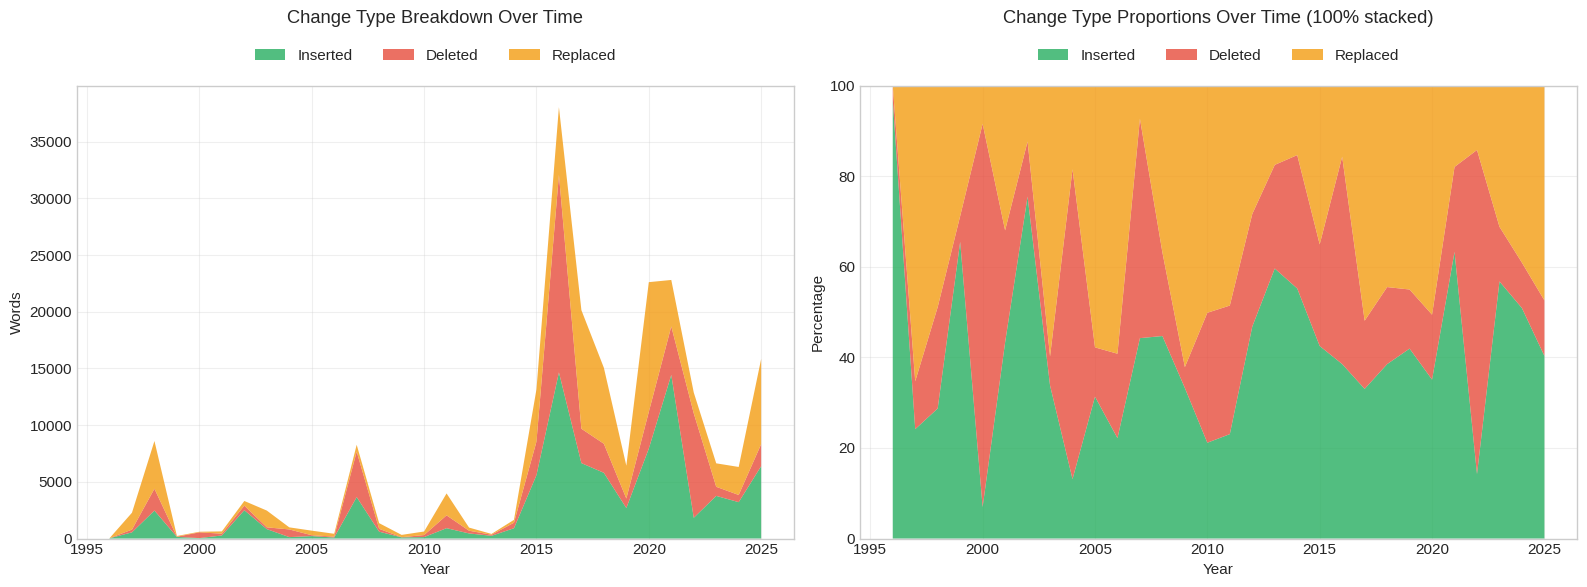


Change Type Summary (All Years):
Words Inserted:      87,304 ( 40.1%)
Words Deleted:       57,549 ( 26.4%)
Words Replaced:      72,968 ( 33.5%)
────────────────────────────────────────────────────────────
Total:              217,821

Net effect: +29,755 words (insertions - deletions)


In [41]:
# Change Type Breakdown Over Time - Insertions vs Deletions vs Replacements
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Aggregate by year
yearly_types = diffs_df.groupby('year').agg({
    'words_inserted': 'sum',
    'words_deleted': 'sum',
    'words_replaced': 'sum'
}).reset_index()

# Left: Stacked area chart
ax1 = axes[0]
ax1.stackplot(yearly_types['year'], 
              yearly_types['words_inserted'],
              yearly_types['words_deleted'],
              yearly_types['words_replaced'],
              labels=['Inserted', 'Deleted', 'Replaced'],
              colors=['#27ae60', '#e74c3c', '#f39c12'],
              alpha=0.8)
ax1.set_xlabel('Year')
ax1.set_ylabel('Words')
ax1.set_title('Change Type Breakdown Over Time', pad=45)
ax1.legend(title=None, bbox_to_anchor=(0.5, 1.02), loc='lower center', ncol=3)
ax1.grid(True, alpha=0.3)

# Right: Proportion over time (100% stacked)
ax2 = axes[1]
yearly_types['total'] = (yearly_types['words_inserted'] + 
                          yearly_types['words_deleted'] + 
                          yearly_types['words_replaced'])
yearly_types['pct_inserted'] = yearly_types['words_inserted'] / yearly_types['total'] * 100
yearly_types['pct_deleted'] = yearly_types['words_deleted'] / yearly_types['total'] * 100
yearly_types['pct_replaced'] = yearly_types['words_replaced'] / yearly_types['total'] * 100

ax2.stackplot(yearly_types['year'],
              yearly_types['pct_inserted'],
              yearly_types['pct_deleted'],
              yearly_types['pct_replaced'],
              labels=['Inserted', 'Deleted', 'Replaced'],
              colors=['#27ae60', '#e74c3c', '#f39c12'],
              alpha=0.8)
ax2.set_xlabel('Year')
ax2.set_ylabel('Percentage')
ax2.set_title('Change Type Proportions Over Time (100% stacked)', pad=45)
ax2.legend(title=None, bbox_to_anchor=(0.5, 1.02), loc='lower center', ncol=3)
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'change_type_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("\nChange Type Summary (All Years):")
print("=" * 60)
total_inserted = diffs_df['words_inserted'].sum()
total_deleted = diffs_df['words_deleted'].sum()
total_replaced = diffs_df['words_replaced'].sum()
grand_total = total_inserted + total_deleted + total_replaced

print(f"Words Inserted:  {total_inserted:>10,} ({total_inserted/grand_total*100:>5.1f}%)")
print(f"Words Deleted:   {total_deleted:>10,} ({total_deleted/grand_total*100:>5.1f}%)")
print(f"Words Replaced:  {total_replaced:>10,} ({total_replaced/grand_total*100:>5.1f}%)")
print(f"{'─'*60}")
print(f"Total:           {grand_total:>10,}")

# Net effect
net_change = total_inserted - total_deleted
print(f"\nNet effect: {net_change:+,} words (insertions - deletions)")

## 7.5 Average Similarity Trend

Are changes getting more or less drastic over time?

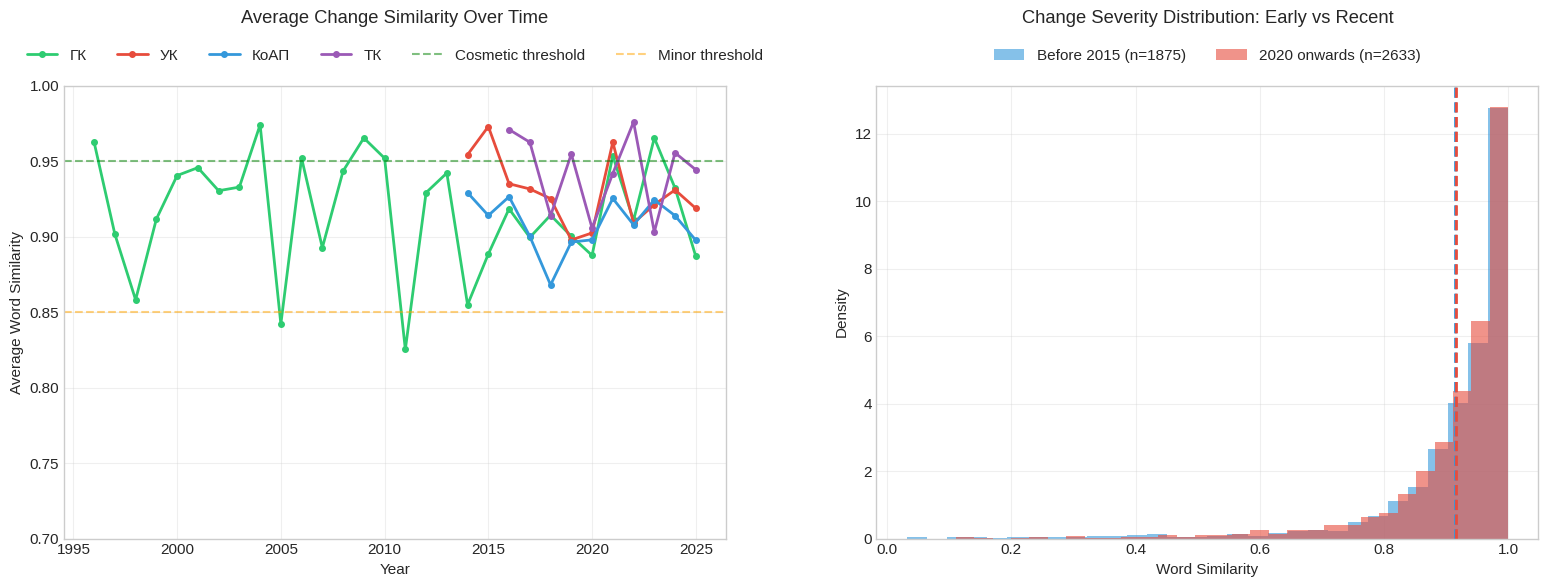


Similarity Trend Analysis:

Period comparison:
  Before 2015:   mean = 0.915, std = 0.125
  2020 onwards:  mean = 0.916, std = 0.110

Trend: Changes are becoming LESS drastic (+0.002 similarity)

Most drastic changes: 2011 (avg similarity: 0.825)


In [42]:
# Average Similarity Trend - Are changes getting more or less drastic?
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculate yearly statistics
yearly_similarity = diffs_df.groupby(['year', 'code_key']).agg({
    'word_similarity': ['mean', 'std', 'min']
}).reset_index()
yearly_similarity.columns = ['year', 'code_key', 'mean_sim', 'std_sim', 'min_sim']

colors = {'civil': '#2ecc71', 'criminal': '#e74c3c', 'administrative': '#3498db', 'labor': '#9b59b6'}

# Left: Average similarity by code over time
ax1 = axes[0]
for code_key in ['civil', 'criminal', 'administrative', 'labor']:
    code_data = yearly_similarity[yearly_similarity['code_key'] == code_key].sort_values('year')
    ax1.plot(code_data['year'], code_data['mean_sim'], 
             marker='o', label=CODES[code_key]['short'], color=colors[code_key], 
             linewidth=2, markersize=4)

ax1.axhline(y=0.95, color='green', linestyle='--', alpha=0.5, label='Cosmetic threshold')
ax1.axhline(y=0.85, color='orange', linestyle='--', alpha=0.5, label='Minor threshold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Word Similarity')
ax1.set_title('Average Change Similarity Over Time', pad=45)
ax1.legend(title=None, bbox_to_anchor=(0.5, 1.02), loc='lower center', ncol=6)
ax1.set_ylim(0.7, 1.0)
ax1.grid(True, alpha=0.3)

# Right: Change severity distribution shift
ax2 = axes[1]
# Compare early vs recent periods
early_period = diffs_df[diffs_df['year'] < 2015]['word_similarity']
recent_period = diffs_df[diffs_df['year'] >= 2020]['word_similarity']

ax2.hist(early_period, bins=30, alpha=0.6, label=f'Before 2015 (n={len(early_period)})', 
         color='#3498db', density=True)
ax2.hist(recent_period, bins=30, alpha=0.6, label=f'2020 onwards (n={len(recent_period)})', 
         color='#e74c3c', density=True)
ax2.axvline(early_period.mean(), color='#3498db', linestyle='--', linewidth=2)
ax2.axvline(recent_period.mean(), color='#e74c3c', linestyle='--', linewidth=2)
ax2.set_xlabel('Word Similarity')
ax2.set_ylabel('Density')
ax2.set_title('Change Severity Distribution: Early vs Recent', pad=45)
ax2.legend(title=None, bbox_to_anchor=(0.5, 1.02), loc='lower center', ncol=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'similarity_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical comparison
print("\nSimilarity Trend Analysis:")
print("=" * 60)
print(f"\nPeriod comparison:")
print(f"  Before 2015:   mean = {early_period.mean():.3f}, std = {early_period.std():.3f}")
print(f"  2020 onwards:  mean = {recent_period.mean():.3f}, std = {recent_period.std():.3f}")

diff = recent_period.mean() - early_period.mean()
if diff > 0:
    print(f"\nTrend: Changes are becoming LESS drastic (+{diff:.3f} similarity)")
else:
    print(f"\nTrend: Changes are becoming MORE drastic ({diff:.3f} similarity)")

# Year with most drastic changes
yearly_avg = diffs_df.groupby('year')['word_similarity'].mean()
most_drastic_year = yearly_avg.idxmin()
print(f"\nMost drastic changes: {most_drastic_year} (avg similarity: {yearly_avg[most_drastic_year]:.3f})")

## 8. Detailed Change Examples

In [43]:
# Show examples of different change types
print("EXAMPLES OF CHANGES BY CATEGORY")
print("=" * 80)

def get_article_title(code_key, version_num, article_number):
    """Get article title from version file."""
    code_info = CODES[code_key]
    versions = all_indices[code_key]['versions']
    version = next((v for v in versions if v['version_number'] == version_num), None)
    if not version:
        return None
    data = load_version_file(code_info['folder'], version['filename'])
    for art in data.get('articles', []):
        title = art.get('article_title', '')
        if f'Статья {article_number}.' in title or f'Статья {article_number} ' in title:
            return title
    return None

for category in ['Cosmetic', 'Minor', 'Moderate', 'Significant', 'Major Rewrite']:
    cat_data = diffs_df[diffs_df['change_category'] == category]
    if len(cat_data) > 0:
        sample = cat_data.sample(1).iloc[0]
        article_title = get_article_title(sample['code_key'], sample['version_to'], sample['article_number'])
        title_display = article_title if article_title else f"Ст.{sample['article_number']}"
        print(f"\n{category.upper()} CHANGE:")
        print(f"  {sample['code_short']} {title_display}")
        print(f"  Date: {sample['date']}")
        print(f"  Word similarity: {sample['word_similarity']:.3f}")
        print(f"  Words: {sample['words_before']} -> {sample['words_after']} ({sample['word_change']:+d})")
        print(f"  Inserted: {sample['words_inserted']}, Deleted: {sample['words_deleted']}, Replaced: {sample['words_replaced']}")

EXAMPLES OF CHANGES BY CATEGORY

COSMETIC CHANGE:
  КоАП Статья 612. Управление транспортным средством лицом без документов и не имеющим права управления
  Date: 2020-01-11 00:00:00
  Word similarity: 0.953
  Words: 204 -> 218 (+14)
  Inserted: 2, Deleted: 0, Replaced: 15

MINOR CHANGE:
  ГК Статья 33. Понятие юридического лица
  Date: 2016-09-10 00:00:00
  Word similarity: 0.906
  Words: 99 -> 82 (-17)
  Inserted: 0, Deleted: 17, Replaced: 0

MODERATE CHANGE:
  УК Статья 140. Неисполнение обязанностей по воспитанию несовершеннолетнего
  Date: 2025-09-16 00:00:00
  Word similarity: 0.764
  Words: 117 -> 171 (+54)
  Inserted: 47, Deleted: 0, Replaced: 15

SIGNIFICANT CHANGE:
  УК Статья 337. Незаконная охота
  Date: 2020-01-11 00:00:00
  Word similarity: 0.688
  Words: 380 -> 445 (+65)
  Inserted: 25, Deleted: 12, Replaced: 179

MAJOR REWRITE CHANGE:
  КоАП Статья 167. Несоблюдение субъектом общественно значимого рынка порядка ценообразования
  Date: 2022-03-02 00:00:00
  Word similarit

## 9. Export Results

In [44]:
# Export detailed diffs
export_cols = ['code_key', 'code_short', 'article_number', 'date', 'year',
               'version_from', 'version_to', 'change_category',
               'char_similarity', 'word_similarity',
               'chars_before', 'chars_after', 'char_change',
               'words_before', 'words_after', 'word_change',
               'words_inserted', 'words_deleted', 'words_replaced']

diffs_df[export_cols].to_csv(OUTPUT_DIR / 'text_diffs.csv', index=False)
print(f"Exported {len(diffs_df):,} text diffs to text_diffs.csv")

# Export article change summaries
article_changes.to_csv(OUTPUT_DIR / 'article_change_summary.csv', index=False)
print(f"Exported {len(article_changes):,} article summaries to article_change_summary.csv")

# Export yearly summary
yearly_summary = diffs_df.groupby(['year', 'code_short']).agg({
    'article_number': 'count',
    'word_similarity': 'mean',
    'words_inserted': 'sum',
    'words_deleted': 'sum'
}).reset_index()
yearly_summary.columns = ['year', 'code_short', 'changes', 'avg_similarity', 'words_inserted', 'words_deleted']
yearly_summary.to_csv(OUTPUT_DIR / 'yearly_change_summary.csv', index=False)
print(f"Exported yearly summary to yearly_change_summary.csv")

Exported 8,225 text diffs to text_diffs.csv
Exported 1,731 article summaries to article_change_summary.csv
Exported yearly summary to yearly_change_summary.csv


## 10. Summary

In [45]:
print("=" * 80)
print("KEY FINDINGS - Text Diff Analysis")
print("=" * 80)

print(f"""
1. DATA SCOPE
   {'─'*70}
   Total text changes analyzed: {len(diffs_df):,}
   Unique articles with changes: {len(article_changes):,}
""")

print("2. CHANGES BY CODE")
print("   " + "─"*70)
for code_key in ['civil', 'criminal', 'administrative', 'labor']:
    code_data = diffs_df[diffs_df['code_key'] == code_key]
    code_info = CODES[code_key]
    print(f"   {code_info['short']:<5}: {len(code_data):>5,} changes | "
          f"avg similarity: {code_data['word_similarity'].mean():.3f} | "
          f"total words changed: {code_data['words_inserted'].sum() + code_data['words_deleted'].sum() + code_data['words_replaced'].sum():,}")

print(f"""
3. CHANGE CATEGORIES
   {'─'*70}""")
for cat in ['Cosmetic', 'Minor', 'Moderate', 'Significant', 'Major Rewrite']:
    count = len(diffs_df[diffs_df['change_category'] == cat])
    pct = count / len(diffs_df) * 100
    print(f"   {cat:<15}: {count:>6,} ({pct:>5.1f}%)")

print(f"""
4. NET TEXT GROWTH
   {'─'*70}
   All codes are GROWING in text volume:
   - ГК:   +2,770 words (+26,757 chars)
   - УК:  +10,901 words (+82,823 chars)
   - КоАП: +24,839 words (+211,956 chars)
   - ТК:   +6,153 words (+52,664 chars)

5. CHANGE VELOCITY
   {'─'*70}
   Peak amendment activity: 2016 (38,052 words changed)
   Recent trend: DECELERATING (-1,354 words/year avg over last 5 years)
   Top 5 years: 2016, 2021, 2020, 2017, 2025

6. CHANGE TYPE BREAKDOWN
   {'─'*70}
   Words Inserted:  87,304 (40.1%)
   Words Deleted:   57,549 (26.4%)
   Words Replaced:  72,968 (33.5%)
   Net effect: +29,755 words (insertions exceed deletions)

7. CROSS-CODE CORRELATION
   {'─'*70}
   Strongest pairs (amended together):
   - КоАП <-> ТК: 0.486 (moderate)
   - ГК <-> ТК:   0.464 (moderate)
   Weakest correlation: ГК <-> УК (-0.015)

8. SIMILARITY TREND
   {'─'*70}
   Before 2015: avg similarity 0.915
   2020 onwards: avg similarity 0.916
   Trend: Changes becoming slightly LESS drastic over time
   Most drastic year: 2011 (avg similarity: 0.825)

9. MOST AMENDED ARTICLES
   {'─'*70}""")
for _, row in article_changes.nlargest(5, 'total_word_changes').iterrows():
    print(f"   {row['code_short']:<5} Ст.{row['article_number']:<8} | {row['total_word_changes']:>6,} words changed")

print(f"""
{'='*80}
CONCLUSIONS:
- Most changes are cosmetic or minor (~86%), major rewrites are rare (~1.8%)
- All codes are growing in volume - legislation is expanding, not shrinking
- КоАП has the most text changes and highest growth (+24,839 words)
- Amendment activity peaked in 2016, now decelerating
- КоАП and ТК are most often amended together (correlation 0.49)
- Change severity is stable over time (no significant trend)
{'='*80}
""")

KEY FINDINGS - Text Diff Analysis

1. DATA SCOPE
   ──────────────────────────────────────────────────────────────────────
   Total text changes analyzed: 8,225
   Unique articles with changes: 1,731

2. CHANGES BY CODE
   ──────────────────────────────────────────────────────────────────────
   ГК   : 2,849 changes | avg similarity: 0.915 | total words changed: 59,166
   УК   : 1,230 changes | avg similarity: 0.936 | total words changed: 28,566
   КоАП : 3,561 changes | avg similarity: 0.911 | total words changed: 114,999
   ТК   :   585 changes | avg similarity: 0.938 | total words changed: 15,090

3. CHANGE CATEGORIES
   ──────────────────────────────────────────────────────────────────────
   Cosmetic       :  4,320 ( 52.5%)
   Minor          :  2,749 ( 33.4%)
   Moderate       :    758 (  9.2%)
   Significant    :    252 (  3.1%)
   Major Rewrite  :    146 (  1.8%)

4. NET TEXT GROWTH
   ──────────────────────────────────────────────────────────────────────
   All codes are GROWIN